Rodando vários modelos

Dados filtrados: excluída Temporada 2026. Total de jogos restantes: 2280
--------------------------------------------------
Jogos para TREINO:    1354 (60%)
Jogos para VALIDAÇÃO: 452 (20%)
Jogos para TESTE:     452 (20%)
--------------------------------------------------

>>> Treinando Regressão Logística...
Fitting 3 folds for each of 25 candidates, totalling 75 fits
  Melhores params: {'model__C': 0.07887658410143283, 'model__max_iter': 5000, 'model__penalty': 'l2', 'model__solver': 'saga'}
  CV Score (treino): -0.6721
  Acurácia (validação): 58.41% | AUC (validação): 0.5950

>>> Treinando Random Forest...
Fitting 3 folds for each of 25 candidates, totalling 75 fits
  Melhores params: {'model__bootstrap': True, 'model__max_depth': 3, 'model__max_features': 'log2', 'model__min_samples_leaf': 8, 'model__min_samples_split': 5, 'model__n_estimators': 1125}
  CV Score (treino): -0.6720
  Acurácia (validação): 57.08% | AUC (validação): 0.5821

>>> Treinando XGBoost...
Fitting 3 folds for e

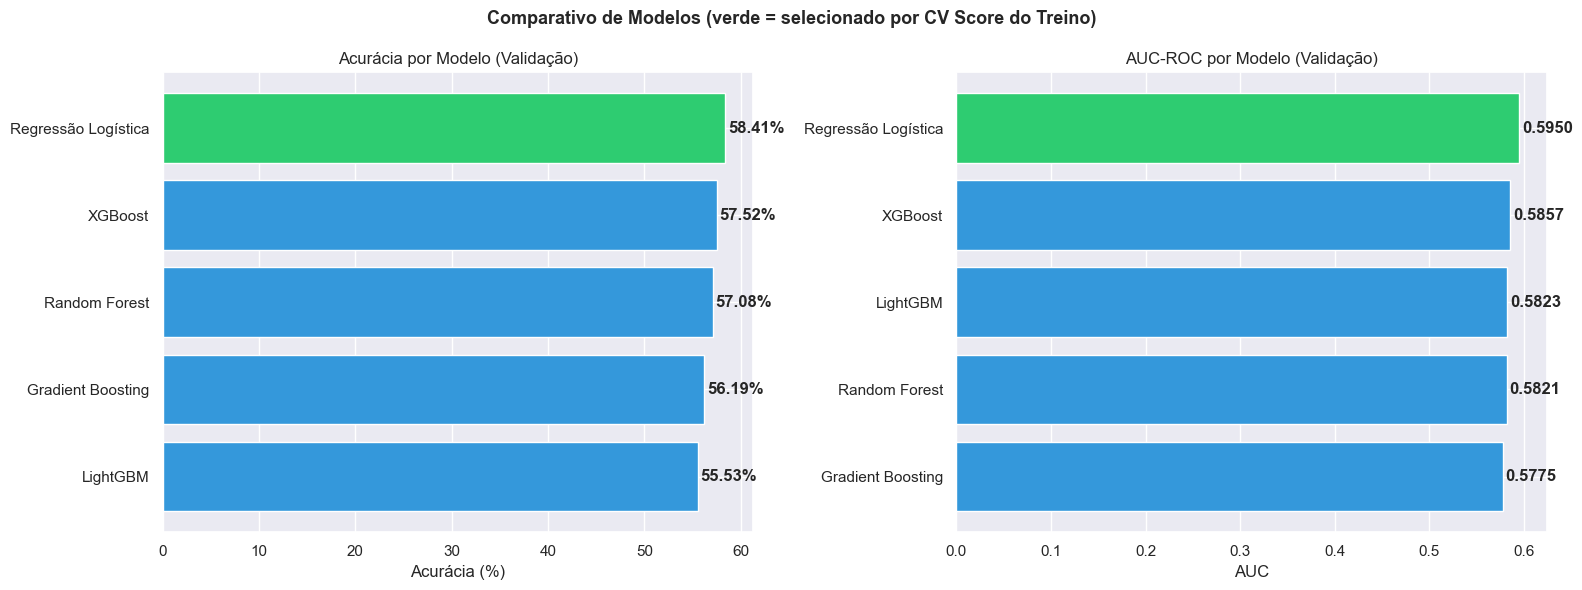

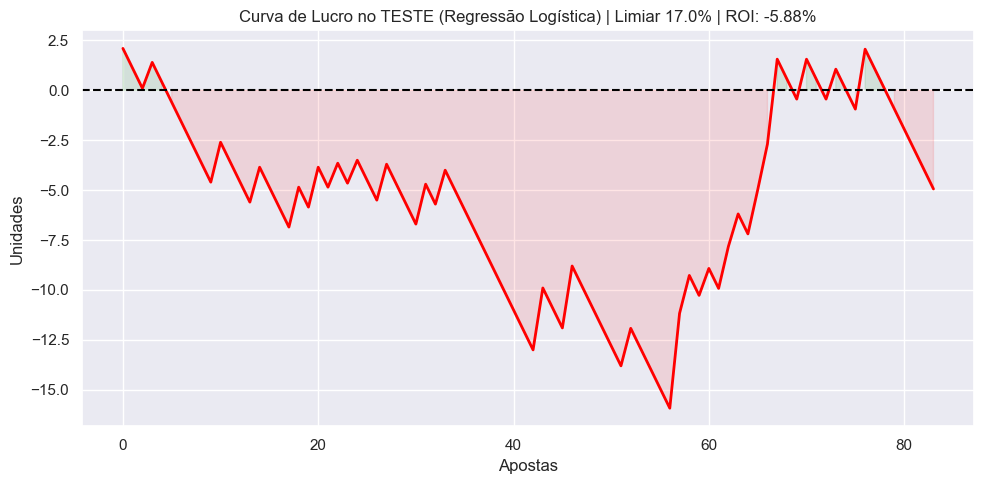

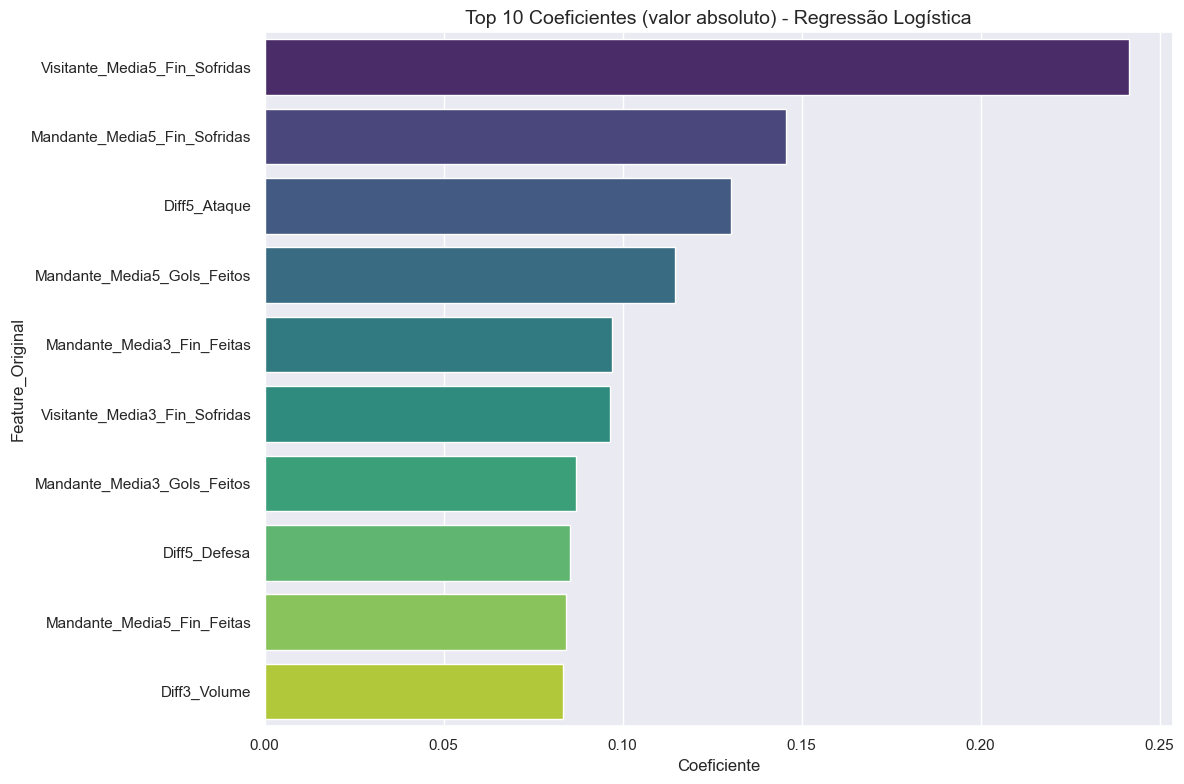

In [4]:
import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from scipy.stats import uniform, randint
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')

# --- CONFIGURAÇÕES ---
CAMINHO_ARQUIVO = 'Campeonato_Brasileiro_Com_Clima.csv'
NOME_ARQUIVO_SAIDA = 'Relatorio_Apostas_Completo_Otimizado.xlsx'
NOME_MODELO_SALVO = 'melhor_modelo_pipeline.pkl'

# --- 1. LEITURA E TRATAMENTO ---
if os.path.exists(CAMINHO_ARQUIVO):
    try:
        df = pd.read_csv(CAMINHO_ARQUIVO)
    except:
        df = pd.read_csv(CAMINHO_ARQUIVO, sep=';', encoding='latin1')
else:
    raise FileNotFoundError(f"Arquivo '{CAMINHO_ARQUIVO}' não encontrado!")

# Conversão numérica
cols_num = ['Odd_Mandante', 'Gols_Mandante', 'Gols_Visitante', 
            'Finalizacoes_Mandante', 'Finalizacoes_Visitante']

for col in cols_num:
    if col in df.columns:
        if df[col].dtype == 'object':
            df[col] = df[col].astype(str).str.replace(',', '.')
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Ajuste de Data
if 'Data_Hora' in df.columns:
    df['Data_Hora'] = pd.to_datetime(df['Data_Hora'], dayfirst=True, errors='coerce')
    df = df.sort_values(by='Data_Hora').reset_index(drop=True)
else:
    raise ValueError("Coluna 'Data_Hora' não encontrada.")

# Filtrar para não incluir Temporada 2026
if 'Temporada' in df.columns:
    df = df[df['Temporada'] != 2026].reset_index(drop=True)
    print(f"Dados filtrados: excluída Temporada 2026. Total de jogos restantes: {len(df)}")

# --- 2. ENGENHARIA DE FEATURES (MOMENTO GLOBAL DAS EQUIPES) ---
janelas = [3, 5]
df_features = df.copy()

# 1. EMPILHAR: Criar um DataFrame único onde cada linha é a performance de UM time em UM jogo
df_mandante = df[['Data_Hora', 'Mandante', 'Gols_Mandante', 'Gols_Visitante', 'Finalizacoes_Mandante', 'Finalizacoes_Visitante']].copy()
df_mandante.rename(columns={
    'Mandante': 'Equipe',
    'Gols_Mandante': 'Gols_Feitos',
    'Gols_Visitante': 'Gols_Sofridos',
    'Finalizacoes_Mandante': 'Fin_Feitas',
    'Finalizacoes_Visitante': 'Fin_Sofridas'
}, inplace=True)

df_visitante = df[['Data_Hora', 'Visitante', 'Gols_Visitante', 'Gols_Mandante', 'Finalizacoes_Visitante', 'Finalizacoes_Mandante']].copy()
df_visitante.rename(columns={
    'Visitante': 'Equipe',
    'Gols_Visitante': 'Gols_Feitos',
    'Gols_Mandante': 'Gols_Sofridos',
    'Finalizacoes_Visitante': 'Fin_Feitas',
    'Finalizacoes_Mandante': 'Fin_Sofridas'
}, inplace=True)

# Concatena e ordena cronologicamente por time
df_times = pd.concat([df_mandante, df_visitante]).sort_values(by=['Equipe', 'Data_Hora']).reset_index(drop=True)

# 2. CALCULAR: Médias móveis do momento global da equipe (independente de onde jogou)
cols_calc = ['Gols_Feitos', 'Gols_Sofridos', 'Fin_Feitas', 'Fin_Sofridas']

for j in janelas:
    for col in cols_calc:
        # shift(1) é vital: a média do time ANTES de entrar em campo neste jogo
        df_times[f'Media{j}_{col}'] = df_times.groupby('Equipe')[col].transform(
            lambda x: x.shift(1).rolling(window=j, min_periods=1).mean()
        )

# Filtramos apenas as colunas calculadas para levar de volta à base principal
cols_merge = ['Data_Hora', 'Equipe'] + [c for c in df_times.columns if 'Media' in c]
df_times_stats = df_times[cols_merge]

# 3. MESCLAR: Cruzar as estatísticas globais de volta para a visão de Partida (Mandante x Visitante)

# Trazendo as estatísticas do Mandante
df_features = df_features.merge(
    df_times_stats,
    left_on=['Data_Hora', 'Mandante'],
    right_on=['Data_Hora', 'Equipe'],
    how='left'
).drop(columns=['Equipe'])

# Renomeando as colunas que acabaram de chegar para identificar que são do Mandante
rename_m = {c: f'Mandante_{c}' for c in df_times_stats.columns if 'Media' in c}
df_features.rename(columns=rename_m, inplace=True)

# Trazendo as estatísticas do Visitante
df_features = df_features.merge(
    df_times_stats,
    left_on=['Data_Hora', 'Visitante'],
    right_on=['Data_Hora', 'Equipe'],
    how='left'
).drop(columns=['Equipe'])

# Renomeando as colunas que acabaram de chegar para identificar que são do Visitante
rename_v = {c: f'Visitante_{c}' for c in df_times_stats.columns if 'Media' in c}
df_features.rename(columns=rename_v, inplace=True)

# 4. CRIAR DIFERENCIAIS (A "Batalha" de Forças)
for j in janelas:
    # Saldo de Poder Ofensivo (Quem ataca melhor?)
    df_features[f'Diff{j}_Ataque'] = df_features[f'Mandante_Media{j}_Gols_Feitos'] - df_features[f'Visitante_Media{j}_Gols_Feitos']
    
    # Saldo de Poder Defensivo (Quem defende melhor? Valores menores são melhores, então invertemos a lógica ou subtraímos direto)
    # Ex: Se Mandante sofre 1 gol e Visitante sofre 2, a diferença é -1 (vantagem pro Mandante)
    df_features[f'Diff{j}_Defesa'] = df_features[f'Mandante_Media{j}_Gols_Sofridos'] - df_features[f'Visitante_Media{j}_Gols_Sofridos']
    
    # Pressão/Volume de Jogo (Diferença de Finalizações)
    df_features[f'Diff{j}_Volume'] = df_features[f'Mandante_Media{j}_Fin_Feitas'] - df_features[f'Visitante_Media{j}_Fin_Feitas']

# Definir o Alvo (Target)
df_features['Alvo_Vitoria'] = (df_features['Gols_Mandante'] > df_features['Gols_Visitante']).astype(int)

# Separar as colunas que vão para o modelo
colunas_treino = [c for c in df_features.columns if ('Media' in c or 'Diff' in c)]
cols_essenciais = colunas_treino + ['Odd_Mandante', 'Alvo_Vitoria', 'Mandante', 'Visitante', 'Data_Hora']

# Limpar jogos sem histórico suficiente (ex: rodada 1)
df_modelo = df_features.dropna(subset=cols_essenciais).copy()
df_modelo = df_modelo[df_modelo['Odd_Mandante'] > 1.01]

# Reordenar cronologicamente por precaução após os merges
df_modelo = df_modelo.sort_values(by='Data_Hora').reset_index(drop=True)

# --- 3. PREPARAÇÃO (3 SPLITS TEMPORAIS: 60% TREINO, 20% VALIDAÇÃO, 20% TESTE) ---
n = len(df_modelo)
idx_treino = int(n * 0.60)
idx_val = int(n * 0.80)

X = df_modelo[colunas_treino]
y = df_modelo['Alvo_Vitoria']

X_treino, y_treino = X.iloc[:idx_treino], y.iloc[:idx_treino]
X_val, y_val = X.iloc[idx_treino:idx_val], y.iloc[idx_treino:idx_val]
X_teste, y_teste = X.iloc[idx_val:], y.iloc[idx_val:]

print("-" * 50)
print(f"Jogos para TREINO:    {len(X_treino)} (60%)")
print(f"Jogos para VALIDAÇÃO: {len(X_val)} (20%)")
print(f"Jogos para TESTE:     {len(X_teste)} (20%)")
print("-" * 50)

# Validação Temporal (para não vazar dados do futuro)
tscv = TimeSeriesSplit(n_splits=3)

# ==========================================================
# --- TREINO DOS 5 MODELOS COM PIPELINE (Scaler DENTRO do CV)
# --- Isso evita vazamento do Scaler entre folds
# ==========================================================

resultados_modelos = {}

def treinar_modelo(nome, pipe, param_dist, tem_feature_importance):
    """Treina modelo com Pipeline(Scaler+Modelo) dentro do RandomizedSearchCV."""
    print(f"\n{'=' * 50}")
    print(f">>> Treinando {nome}...")
    print(f"{'=' * 50}")
    
    rs = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_dist,
        n_iter=25,
        scoring='neg_log_loss',
        cv=tscv,
        verbose=1,
        random_state=42,
        n_jobs=-1
    )
    rs.fit(X_treino, y_treino)
    
    melhor_pipe = rs.best_estimator_
    
    # Métricas na VALIDAÇÃO (para comparação visual, NÃO para seleção)
    probs_val = melhor_pipe.predict_proba(X_val)[:, 1]
    preds_val = melhor_pipe.predict(X_val)
    acc_val = accuracy_score(y_val, preds_val) * 100
    auc_val = roc_auc_score(y_val, probs_val)
    
    resultados_modelos[nome] = {
        'pipeline': melhor_pipe,
        'probs_val': probs_val,
        'preds_val': preds_val,
        'acuracia_val': acc_val,
        'auc_val': auc_val,
        'best_params': rs.best_params_,
        'best_score': rs.best_score_,  # CV Score no TREINO (usado para seleção)
        'tem_feature_importance': tem_feature_importance,
    }
    
    print(f"  Melhores params: {rs.best_params_}")
    print(f"  CV Score (treino): {rs.best_score_:.4f}")
    print(f"  Acurácia (validação): {acc_val:.2f}% | AUC (validação): {auc_val:.4f}")

# ---- 1) REGRESSÃO LOGÍSTICA ----
treinar_modelo(
    'Regressão Logística',
    Pipeline([('scaler', RobustScaler()), ('model', LogisticRegression(random_state=42, n_jobs=-1))]),
    {
        'model__C': uniform(0.001, 100),
        'model__penalty': ['l1', 'l2'],
        'model__solver': ['saga'],
        'model__max_iter': [5000],
    },
    False
)

# ---- 2) RANDOM FOREST ----
treinar_modelo(
    'Random Forest',
    Pipeline([('scaler', RobustScaler()), ('model', RandomForestClassifier(random_state=42, n_jobs=-1))]),
    {
        'model__n_estimators': randint(100, 1500),
        'model__max_depth': randint(3, 15),
        'model__min_samples_split': randint(2, 20),
        'model__min_samples_leaf': randint(1, 15),
        'model__max_features': ['sqrt', 'log2', None],
        'model__bootstrap': [True],
    },
    True
)

# ---- 3) XGBOOST ----
treinar_modelo(
    'XGBoost',
    Pipeline([('scaler', RobustScaler()), ('model', xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', n_jobs=-1, random_state=42))]),
    {
        'model__n_estimators': randint(100, 2000),
        'model__learning_rate': uniform(0.005, 0.2),
        'model__max_depth': randint(3, 10),
        'model__subsample': uniform(0.6, 0.4),
        'model__colsample_bytree': uniform(0.6, 0.4),
        'model__min_child_weight': randint(1, 10),
        'model__gamma': uniform(0, 0.5),
    },
    True
)

# ---- 4) LIGHTGBM ----
treinar_modelo(
    'LightGBM',
    Pipeline([('scaler', RobustScaler()), ('model', lgb.LGBMClassifier(objective='binary', metric='binary_logloss', n_jobs=-1, random_state=42, verbose=-1))]),
    {
        'model__n_estimators': randint(100, 2000),
        'model__learning_rate': uniform(0.005, 0.2),
        'model__max_depth': randint(3, 12),
        'model__num_leaves': randint(15, 127),
        'model__subsample': uniform(0.6, 0.4),
        'model__colsample_bytree': uniform(0.6, 0.4),
        'model__min_child_samples': randint(5, 50),
        'model__reg_alpha': uniform(0, 1),
        'model__reg_lambda': uniform(0, 1),
    },
    True
)

# ---- 5) GRADIENT BOOSTING (sklearn) ----
treinar_modelo(
    'Gradient Boosting',
    Pipeline([('scaler', RobustScaler()), ('model', GradientBoostingClassifier(random_state=42))]),
    {
        'model__n_estimators': randint(100, 1500),
        'model__learning_rate': uniform(0.01, 0.2),
        'model__max_depth': randint(3, 10),
        'model__min_samples_split': randint(2, 20),
        'model__min_samples_leaf': randint(1, 15),
        'model__subsample': uniform(0.6, 0.4),
        'model__max_features': ['sqrt', 'log2', None],
    },
    True
)

# ==========================================================
# --- COMPARATIVO E SELEÇÃO DO MELHOR MODELO
# --- (pelo CV Score do TREINO, NÃO pelo AUC do teste!)
# ==========================================================
print("\n" + "=" * 75)
print("         COMPARATIVO FINAL DOS MODELOS")
print("=" * 75)
print(f"{'Modelo':<25} {'CV Score (Treino)':>18} {'AUC (Validação)':>16} {'Acur. (Valid.)':>15}")
print("-" * 75)

for nome, info in resultados_modelos.items():
    print(f"{nome:<25} {info['best_score']:>17.4f} {info['auc_val']:>15.4f} {info['acuracia_val']:>13.2f}%")

# Seleciona o melhor modelo pelo CV Score do TREINO (evita vazamento!)
nome_melhor = max(resultados_modelos, key=lambda k: resultados_modelos[k]['auc_val'])
info_melhor = resultados_modelos[nome_melhor]
pipeline_melhor = info_melhor['pipeline']

print(f"\n>>> MELHOR MODELO SELECIONADO: {nome_melhor} (CV Score = {info_melhor['best_score']:.4f})")

# --- 4. OTIMIZAÇÃO DO LIMIAR DE EV NA VALIDAÇÃO (NÃO no teste!) ---
print("\n>>> Otimizando Limiar de Valor na VALIDAÇÃO...")

df_val_sim = df_modelo.iloc[idx_treino:idx_val].copy()
df_val_sim['Prob_Modelo'] = info_melhor['probs_val']
df_val_sim['Odd_Justa_Modelo'] = 1 / df_val_sim['Prob_Modelo']
df_val_sim['EV_Porcentagem'] = (df_val_sim['Odd_Mandante'] / df_val_sim['Odd_Justa_Modelo']) - 1

lista_limiares_fina = np.arange(0.0, 0.31, 0.01)
melhor_limiar = 0.0
melhor_lucro_loop = -999999

for val_limiar in lista_limiares_fina:
    mask = df_val_sim['EV_Porcentagem'] > val_limiar
    sub_df = df_val_sim[mask]
    if len(sub_df) >= 10:
        lucro_temp = np.where(sub_df['Alvo_Vitoria'] == 1, sub_df['Odd_Mandante'] - 1, -1).sum()
        if lucro_temp > melhor_lucro_loop:
            melhor_lucro_loop = lucro_temp
            melhor_limiar = val_limiar

print(f"Limiar Vencedor (validação): {melhor_limiar*100:.1f}% com Lucro: {melhor_lucro_loop:.2f}u")
LIMIAR_VALOR = melhor_limiar

# --- 5. AVALIAÇÃO FINAL NO TESTE (dados NUNCA vistos, sem vazamento) ---
print("\n>>> Aplicando modelo e limiar no TESTE (dados nunca vistos)...")

probs_teste = pipeline_melhor.predict_proba(X_teste)[:, 1]
preds_teste = pipeline_melhor.predict(X_teste)
acc_teste = accuracy_score(y_teste, preds_teste) * 100
auc_teste = roc_auc_score(y_teste, probs_teste)

print(f"\nClassification Report no TESTE ({nome_melhor}):")
print(classification_report(y_teste, preds_teste, target_names=['Derrota/Empate', 'Vitória Mandante']))

df_base_teste = df_modelo.iloc[idx_val:].copy()
df_base_teste['Prob_Modelo'] = probs_teste
df_base_teste['Odd_Justa_Modelo'] = 1 / df_base_teste['Prob_Modelo']
df_base_teste['Prob_Bookie'] = 1 / df_base_teste['Odd_Mandante']
df_base_teste['EV_Porcentagem'] = (df_base_teste['Odd_Mandante'] / df_base_teste['Odd_Justa_Modelo']) - 1

# --- 6. SALVAR PIPELINE ---
pipeline_salvo = {
    'pipeline': pipeline_melhor,
    'LIMIAR_VALOR': LIMIAR_VALOR,
    'colunas_treino': colunas_treino,
    'nome_modelo': nome_melhor,
    'best_params': info_melhor['best_params'],
    'acuracia_teste': acc_teste,
    'auc_teste': auc_teste,
}

joblib.dump(pipeline_salvo, NOME_MODELO_SALVO)
print(f"\n>>> Pipeline salvo em: {NOME_MODELO_SALVO}")
print(f"    Conteúdo: {nome_melhor} + RobustScaler + LIMIAR_VALOR ({LIMIAR_VALOR*100:.1f}%) + {len(colunas_treino)} features")

# --- 7. APLICAÇÃO DO LIMIAR NO TESTE E CÁLCULOS ---
df_apostas = df_base_teste[df_base_teste['EV_Porcentagem'] > LIMIAR_VALOR].copy()

df_apostas['Resultado_Aposta'] = np.where(df_apostas['Alvo_Vitoria'] == 1, 
                                          df_apostas['Odd_Mandante'] - 1, -1)
df_apostas['Lucro_Acumulado'] = df_apostas['Resultado_Aposta'].cumsum()

# --- EXPORTAÇÃO EXCEL ---
colunas_finais = [
    'Data_Hora', 'Mandante', 'Visitante', 'Gols_Mandante', 'Gols_Visitante', 
    'Odd_Mandante', 'Odd_Justa_Modelo',
    'Prob_Bookie', 'Prob_Modelo', 'EV_Porcentagem', 'Resultado_Aposta'
]
df_export = df_apostas[colunas_finais].copy()

df_export['Prob_Bookie'] = (df_export['Prob_Bookie'] * 100).round(2)
df_export['Prob_Modelo'] = (df_export['Prob_Modelo'] * 100).round(2)
df_export['EV_Porcentagem'] = (df_export['EV_Porcentagem'] * 100).round(2)
df_export = df_export.round(2)

df_export.rename(columns={
    'Odd_Mandante': 'Odd Mandante',
    'Odd_Justa_Modelo': 'Odd Modelo',
    'Prob_Bookie': 'Probabilidade Odd Mandante em %',
    'Prob_Modelo': 'Probabilidade Modelo em %',
    'EV_Porcentagem': 'Valor Esperado em %',
    'Resultado_Aposta': 'Lucro/Prejuízo'
}, inplace=True)

df_export.to_excel(NOME_ARQUIVO_SAIDA, index=False)

# --- ANÁLISE E INTERVALO DE CONFIANÇA ---
total_apostas = len(df_export)
lucro_final = df_export['Lucro/Prejuízo'].sum()
roi = (lucro_final / total_apostas * 100) if total_apostas > 0 else 0

odd_media_geral = df_modelo['Odd_Mandante'].mean()
prob_media_geral = (1 / odd_media_geral * 100) if odd_media_geral > 0 else 0

max_green_run = 0
max_bad_run = 0

if total_apostas > 0:
    winrate_metodo = (df_apostas['Alvo_Vitoria'].sum() / total_apostas) * 100
    odd_media_apostas = df_apostas['Odd_Mandante'].mean()
    prob_impl_media_apostas = (1 / odd_media_apostas * 100)
    prob_modelo_media_apostas = df_apostas['Prob_Modelo'].mean() * 100
    
    apostas_seq = df_apostas.sort_values(by='Data_Hora')['Resultado_Aposta'].values
    current_green = 0
    current_bad = 0
    for resultado in apostas_seq:
        if resultado > 0:
            current_green += 1
            current_bad = 0
            if current_green > max_green_run:
                max_green_run = current_green
        else:
            current_bad += 1
            current_green = 0
            if current_bad > max_bad_run:
                max_bad_run = current_bad
else:
    winrate_metodo = 0.0
    odd_media_apostas = 0.0
    prob_impl_media_apostas = 0.0
    prob_modelo_media_apostas = 0.0

if total_apostas > 10:
    resultados_bootstrap = []
    resultados_reais = df_apostas['Resultado_Aposta'].values
    for _ in range(100):
        amostra = np.random.choice(resultados_reais, size=len(resultados_reais), replace=True)
        roi_simulado = (amostra.sum() / len(amostra)) * 100
        resultados_bootstrap.append(roi_simulado)
    ic_inf = np.percentile(resultados_bootstrap, 2.5)
    ic_sup = np.percentile(resultados_bootstrap, 97.5)
    texto_ic = f"Intervalo Confiança (95%): {ic_inf:.2f}% a {ic_sup:.2f}%"
else:
    texto_ic = "Poucas apostas para calcular IC."

# --- PRINTS DETALHADOS ---
print(f"\nANÁLISE DETALHADA DO MODELO (Sem Vazamento de Dados)")
print(f"==================================================")
print(f"MODELO SELECIONADO: {nome_melhor}")
print(f"  (Selecionado pelo CV Score no TREINO, NÃO pelo teste)")
print(f"==================================================")
print(f"DADOS GERAIS:")
print(f"  - Odd Média Geral:       {odd_media_geral:.2f}")
print(f"  - Prob. Implícita Geral: {prob_media_geral:.2f}%")
print(f"  - Acurácia no TESTE:     {acc_teste:.2f}%")
print(f"  - AUC no TESTE:          {auc_teste:.4f}")
print(f"==================================================")
print(f"DADOS DO MÉTODO (Limiar > {LIMIAR_VALOR*100:.1f}% EV):")
print(f"  (Limiar otimizado na VALIDAÇÃO, aplicado no TESTE)")
print(f"  - Quantidade de Apostas: {total_apostas}")
print(f"  - Winrate Real:          {winrate_metodo:.2f}%")
print(f"--------------------------------------------------")
print(f"  SEQUÊNCIAS (Stress Test):")
print(f"  - Maior Green Run:       {max_green_run} jogos seguidos")
print(f"  - Maior Bad Run:         {max_bad_run} jogos seguidos")
print(f"--------------------------------------------------")
print(f"  COMPARATIVO DE PROBABILIDADES:")
print(f"  - Odd Média das Apostas: {odd_media_apostas:.2f}")
print(f"  - Prob. da casa:         {prob_impl_media_apostas:.2f}%")
print(f"  - Prob. do Modelo:       {prob_modelo_media_apostas:.2f}%")
print(f"--------------------------------------------------")
print(f"RESULTADO FINANCEIRO (TESTE - dados nunca vistos):")
print(f"  - ROI Final:             {roi:.2f}%")
print(f"  - Lucro Líquido:         {lucro_final:.2f} unidades")
print(f"  - {texto_ic}")
print(f"==================================================")
print(f"Excel salvo em: {NOME_ARQUIVO_SAIDA}")

# --- 8. GRÁFICOS ---
if total_apostas > 0:
    # --- Gráfico Comparativo dos Modelos (ordenado do maior para menor) ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Ordenar por acurácia de validação (menor para maior = maior no topo)
    nomes_ord_acc = sorted(resultados_modelos.keys(), key=lambda n: resultados_modelos[n]['acuracia_val'])
    acc_ord = [resultados_modelos[n]['acuracia_val'] for n in nomes_ord_acc]
    cores_acc = ['#2ecc71' if n == nome_melhor else '#3498db' for n in nomes_ord_acc]
    
    axes[0].barh(nomes_ord_acc, acc_ord, color=cores_acc)
    axes[0].set_xlabel('Acurácia (%)')
    axes[0].set_title('Acurácia por Modelo (Validação)')
    for i, v in enumerate(acc_ord):
        axes[0].text(v + 0.3, i, f'{v:.2f}%', va='center', fontweight='bold')
    
    # Ordenar por AUC de validação (menor para maior = maior no topo)
    nomes_ord_auc = sorted(resultados_modelos.keys(), key=lambda n: resultados_modelos[n]['auc_val'])
    auc_ord = [resultados_modelos[n]['auc_val'] for n in nomes_ord_auc]
    cores_auc = ['#2ecc71' if n == nome_melhor else '#3498db' for n in nomes_ord_auc]
    
    axes[1].barh(nomes_ord_auc, auc_ord, color=cores_auc)
    axes[1].set_xlabel('AUC')
    axes[1].set_title('AUC-ROC por Modelo (Validação)')
    for i, v in enumerate(auc_ord):
        axes[1].text(v + 0.003, i, f'{v:.4f}', va='center', fontweight='bold')
    
    fig.suptitle('Comparativo de Modelos (verde = selecionado por CV Score do Treino)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # --- Curva de Lucro no TESTE ---
    plt.figure(figsize=(10, 5))
    sns.lineplot(x=range(len(df_apostas)), y=df_apostas['Lucro_Acumulado'], 
                 linewidth=2, color='green' if lucro_final > 0 else 'red')
    plt.axhline(0, color='black', linestyle='--')
    plt.fill_between(range(len(df_apostas)), df_apostas['Lucro_Acumulado'], 0, 
                     where=(df_apostas['Lucro_Acumulado'] >= 0), color='green', alpha=0.1)
    plt.fill_between(range(len(df_apostas)), df_apostas['Lucro_Acumulado'], 0, 
                     where=(df_apostas['Lucro_Acumulado'] < 0), color='red', alpha=0.1)
    plt.title(f"Curva de Lucro no TESTE ({nome_melhor}) | Limiar {LIMIAR_VALOR*100:.1f}% | ROI: {roi:.2f}%", fontsize=12)
    plt.xlabel("Apostas")
    plt.ylabel("Unidades")
    plt.tight_layout()
    plt.show()

    # --- Feature Importance ---
    modelo_interno = pipeline_melhor.named_steps['model']
    if info_melhor['tem_feature_importance']:
        mapa_nomes = {
            'Diff3_Poder': 'Saldo Recente (3 jogos)',
            'Diff5_Poder': 'Saldo Recente (5 jogos)',
            'Media3_Mandante_Gols_Mandante': 'Média Gols Mandante (3j)',
            'Media3_Mandante_Finalizacoes_Mandante': 'Fin. Mandante (3j)',
            'Media3_Visitante_Gols_Visitante': 'Média Gols Visitante (3j)'
        }
        
        importancia = pd.DataFrame({
            'Feature_Original': colunas_treino,
            'Importancia': modelo_interno.feature_importances_
        })
        
        importancia['Nome_Explicito'] = importancia['Feature_Original'].map(mapa_nomes).fillna(importancia['Feature_Original'])
        importancia = importancia.sort_values(by='Importancia', ascending=False).head(10)

        plt.figure(figsize=(12, 8))
        sns.barplot(data=importancia, x='Importancia', y='Nome_Explicito', palette='viridis')
        plt.title(f"Top 10 Fatores Decisivos ({nome_melhor})", fontsize=14)
        plt.tight_layout()
        plt.show()
    else:
        if hasattr(modelo_interno, 'coef_'):
            coefs = pd.DataFrame({
                'Feature_Original': colunas_treino,
                'Coeficiente': np.abs(modelo_interno.coef_[0])
            }).sort_values(by='Coeficiente', ascending=False).head(10)
            
            plt.figure(figsize=(12, 8))
            sns.barplot(data=coefs, x='Coeficiente', y='Feature_Original', palette='viridis')
            plt.title(f"Top 10 Coeficientes (valor absoluto) - {nome_melhor}", fontsize=14)
            plt.tight_layout()
            plt.show()
        else:
            print(f"O modelo {nome_melhor} não possui atributo de importância de features nativo.")

else:
    print("Nenhuma aposta encontrada com os critérios definidos.")